In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/ML/Dummy data set/Per_Trail_EEG-3.xlsx")

In [ ]:
# Convert ASD/TD to 1/0 for ML
df['Label_Class'] = df['DataSet'].apply(
    lambda x: 1 if pd.notna(x) and 'ASD' in x else (0 if pd.notna(x) and 'TD' in x else None)
)

# Select features
features = [
    'AF7_Alpha', 'AF7_Beta', 'AF7_Theta',
    'AF8_Alpha', 'AF8_Beta', 'AF8_Theta',
    'Theta/Alpha_AF7', 'Alpha/Beta_AF7',
    'Theta/Alpha_AF8', 'Alpha/Beta_AF8'
]

X = df[features]
y = df['Label_Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 🔍 GridSearchCV to tune SVM
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

svm = SVC(probability=True, random_state=42)

grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("✅ Best Hyperparameters:", grid.best_params_)
print("🏆 Best Cross-Validated Accuracy: {:.2f}".format(grid.best_score_))

best_svm_model = grid.best_estimator_


✅ Best Hyperparameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
🏆 Best Cross-Validated Accuracy: 0.89


✅ Best K = 3 with accuracy = 0.83


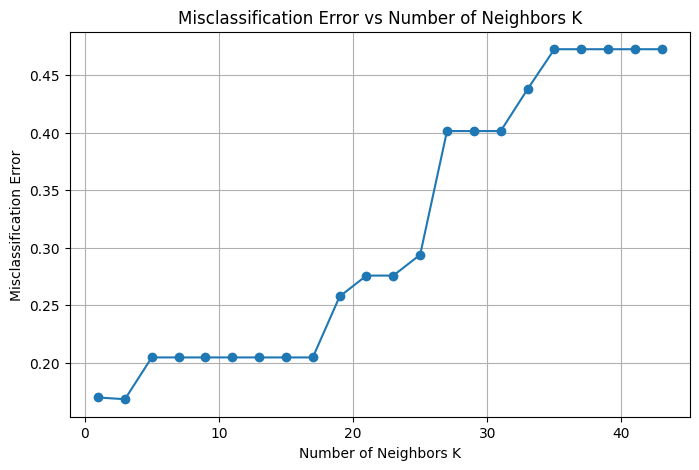

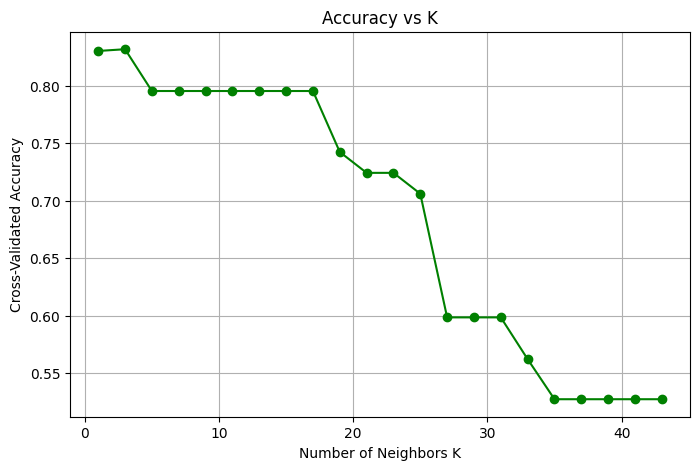

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Define safe K range based on your dataset ---
total_samples = len(X)
max_safe_k = (total_samples * 4) // 5  # 80% of data for training in 5-fold CV
k_range = list(range(1, max_safe_k, 2))  # Odd K values only

# Store accuracy and misclassification error ---
accuracy_scores = []
error_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    accuracy_scores.append(mean_score)
    error_scores.append(1 - mean_score)

# Get best K based on highest accuracy ---
best_k = k_range[np.argmax(accuracy_scores)]
print(f"✅ Best K = {best_k} with accuracy = {max(accuracy_scores):.2f}")

# Plot Misclassification Error ---
plt.figure(figsize=(8, 5))
plt.plot(k_range, error_scores, marker='o')
plt.xlabel("Number of Neighbors K")
plt.ylabel("Misclassification Error")
plt.title("Misclassification Error vs Number of Neighbors K")
plt.grid(True)
plt.show()

# Plot Accuracy Curve too ---
plt.figure(figsize=(8, 5))
plt.plot(k_range, accuracy_scores, marker='o', color='green')
plt.xlabel("Number of Neighbors K")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.show()

# Define KNN with best K for final model evaluation ---
knn_model = KNeighborsClassifier(n_neighbors=best_k)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define and tune the Random Forest model
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],             # Try more trees
    'max_depth': [5, 10, 15, None],              # Explore deeper trees
    'min_samples_split': [2, 4, 6],              # Slightly more aggressive splitting
    'min_samples_leaf': [1, 2, 4],               # Try fewer samples per leaf
    'max_features': ['sqrt', 'log2'],    # How many features to consider
    'bootstrap': [True, False],                  # Whether sampling with replacement
    'criterion': ['gini', 'entropy']             # Splitting strategy
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit and get the best model
grid_search_rf.fit(X_train_scaled, y_train)
best_rf_model = grid_search_rf.best_estimator_

# Print only best params and best score
print("✅ Best Hyperparameters:", grid_search_rf.best_params_)
print("🏆 Best Cross-Validated Accuracy: {:.2f}".format(grid_search_rf.best_score_))


Fitting 5 folds for each of 864 candidates, totalling 4320 fits
✅ Best Hyperparameters: {'bootstrap': False, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
🏆 Best Cross-Validated Accuracy: 0.87


In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
import pandas as pd

# Define individual models
svm_model = best_svm_model
knn_model = KNeighborsClassifier(n_neighbors=best_k)
rf_model = best_rf_model

# Define ensemble model
ensemble_model = VotingClassifier(estimators=[
    ('SVM', svm_model),
    ('KNN', knn_model),
    ('RF', rf_model)
], voting='soft')

# Store models
models = {
    "SVM": svm_model,
    "KNN": knn_model,
    "Random Forest": rf_model,
    "Ensemble": ensemble_model
}

# Prepare to store results
combined_results = {}
classification_reports = {name: {} for name in models}

# Loop through each task
for task_code, task_name in zip([0, 1, 2], ['BM', 'BS', 'NM']):
    task_df = df[df['Label'] == task_code]
    X = task_df[features]
    y = task_df['Label_Class']

    # Split and scale
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        # Store classification report per model per task
        classification_reports[name][task_name] = classification_report(
            y_test, y_pred, target_names=["TD", "ASD"], zero_division=0
        )

        # Calculate task-wise accuracy
        X_test_copy = X_test.copy()
        X_test_copy['true_label'] = y_test.values
        X_test_copy['predicted_label'] = y_pred
        X_test_copy['task_type'] = task_code
        X_test_copy['group'] = y_test.values

        task_group_accuracy = (
            X_test_copy.groupby(['group', 'task_type'])[['true_label', 'predicted_label']]
            .apply(lambda g: (g['true_label'] == g['predicted_label']).mean())
            .unstack(level=1)
        )

        if name not in combined_results:
            combined_results[name] = task_group_accuracy
        else:
            combined_results[name] = pd.concat([combined_results[name], task_group_accuracy], axis=1)

# 🔽 Final Output per Model
for model_name in models.keys():
    print(f"\n===== {model_name} Classification Report =====")
    print("\n".join([f"🔹 Task: {task}\n{classification_reports[model_name][task]}" for task in ['BM', 'BS', 'NM']]))
    print(f"\n🎯 Task-wise Accuracy Within Each Group ({model_name}):")
    print(combined_results[model_name])



===== SVM Classification Report =====
🔹 Task: BM
              precision    recall  f1-score   support

          TD       0.75      1.00      0.86         3
         ASD       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5

🔹 Task: BS
              precision    recall  f1-score   support

          TD       0.75      1.00      0.86         3
         ASD       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5

🔹 Task: NM
              precision    recall  f1-score   support

          TD       1.00      0.33      0.50         3
         ASD       0.50      1.00      0.67         2

    accuracy                           0.60         5
   macro avg       0.75      0.67      0.58         5
we